In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data.csv


In [7]:
historical_df = pd.read_csv("historical_data.csv")
fear_df = pd.read_csv("fear_greed_index.csv")


In [4]:
historical_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [8]:
fear_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [9]:
historical_df.shape


(211224, 16)

In [10]:
fear_df.shape

(2644, 4)

In [11]:
historical_df.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [12]:
fear_df.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [13]:
historical_df.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [14]:
fear_df.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [15]:
historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [16]:
fear_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


#Data Cleaning



In [17]:
historical_df['Timestamp IST'].head()

,Timestamp IST
0,02-12-2024 22:50
1,02-12-2024 22:50
2,02-12-2024 22:50
3,02-12-2024 22:50
4,02-12-2024 22:50


In [18]:
historical_df['Timestamp'].head()

,Timestamp
0,1.730000e+12
1,1.730000e+12
2,1.730000e+12
3,1.730000e+12
4,1.730000e+12


In [19]:
fear_df['date'].head()

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05


In [20]:
historical_df['Timestamp IST'] = pd.to_datetime(historical_df['Timestamp IST'], format = '%d-%m-%Y %H:%M')
fear_df['date'] = pd.to_datetime(fear_df['date'])

In [21]:
historical_df['date'] = historical_df['Timestamp IST'].dt.date
fear_df['date'] = fear_df['date'].dt.date

In [22]:
historical_df[['Timestamp IST', 'date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [23]:
fear_df.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


#Data Merging



In [24]:
merged_df = pd.merge(historical_df, fear_df, on = 'date', how = 'left')

In [25]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


In [26]:
merged_df[['date', 'Coin', 'Closed PnL', 'classification']].head(10)

,date,Coin,Closed PnL,classification
0,2024-12-02,@107,0.0,Extreme Greed
1,2024-12-02,@107,0.0,Extreme Greed
2,2024-12-02,@107,0.0,Extreme Greed
3,2024-12-02,@107,0.0,Extreme Greed
4,2024-12-02,@107,0.0,Extreme Greed
5,2024-12-02,@107,0.0,Extreme Greed
6,2024-12-02,@107,0.0,Extreme Greed
7,2024-12-02,@107,0.0,Extreme Greed
8,2024-12-02,@107,0.0,Extreme Greed
9,2024-12-02,@107,0.0,Extreme Greed


#Exploratory Data Analysis (EDA)


In [27]:
merged_df['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


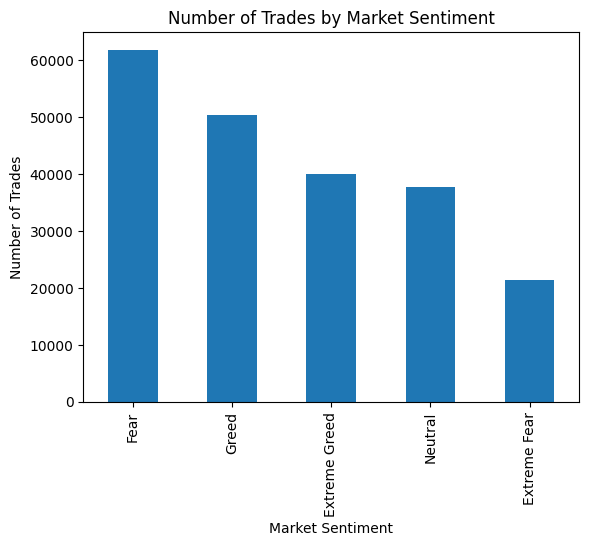

In [28]:
merged_df['classification'].value_counts().plot(kind = 'bar')

plt.title('Number of Trades by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Number of Trades')

plt.show()

In [29]:
sentiment_pnl = merged_df.groupby('classification')['Closed PnL'].mean()
sentiment_pnl

,Closed PnL
classification,
Extreme Fear,34.537862
Extreme Greed,67.892861
Fear,54.290400
Greed,42.743559
Neutral,34.307718


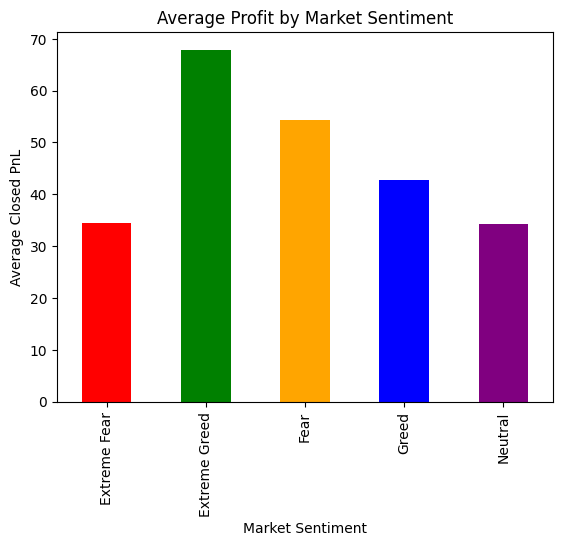

In [30]:
sentiment_pnl.plot(kind = 'bar', color = ['red', 'green', 'orange', 'blue', 'purple'])
plt.title('Average Profit by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

#Median Analysis

The median Closed PnL is 0 across all market sentiment categories, indicating that more than half of the trades in each sentiment category had zero realized profit. This suggests the profit distribution is highly skewed, with the mean being influenced by relatively few high-profit trades.

In [32]:
sentiment_median = merged_df.groupby('classification')['Closed PnL'].median()
sentiment_median

,Closed PnL
classification,
Extreme Fear,0.0
Extreme Greed,0.0
Fear,0.0
Greed,0.0
Neutral,0.0


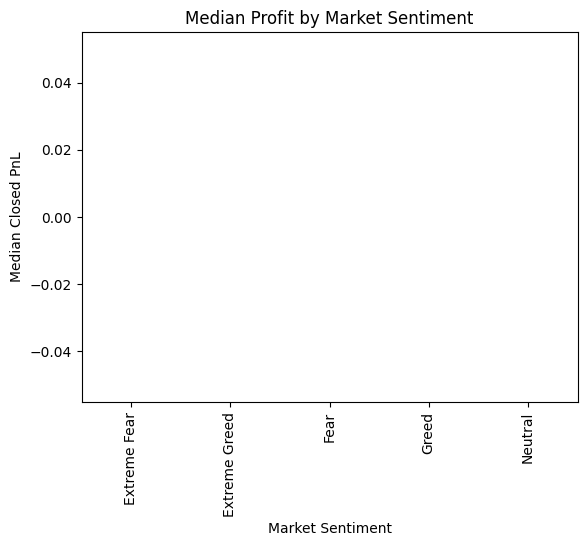

In [35]:
sentiment_median.plot(kind = 'bar', color = ['red', 'green', 'orange', 'blue', 'purple'])
plt.title('Median Profit by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Median Closed PnL')
plt.show()

#Profit by Sentiment

In [36]:
profit_by_sentiment = merged_df.groupby('classification')['Closed PnL'].agg(['mean','sum','count'])
profit_by_sentiment

,mean,sum,count
classification,,,
Extreme Fear,34.537862,7.391102e+05,21400
Extreme Greed,67.892861,2.715171e+06,39992
Fear,54.290400,3.357155e+06,61837
Greed,42.743559,2.150129e+06,50303
Neutral,34.307718,1.292921e+06,37686


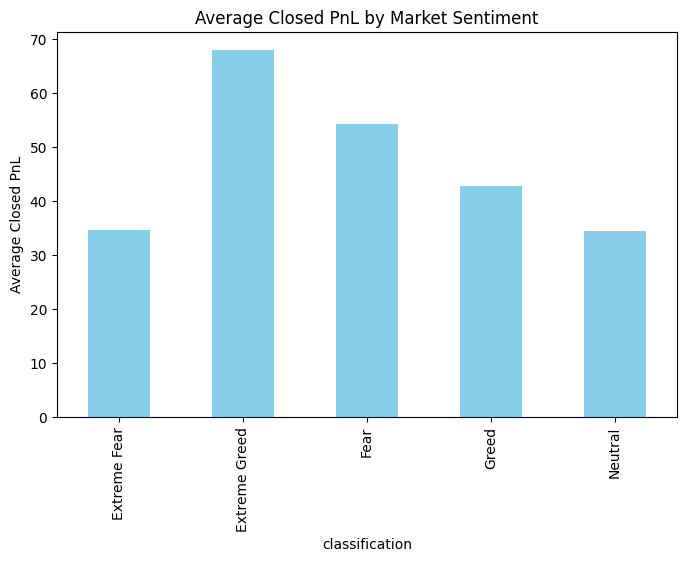

In [37]:
profit_by_sentiment['mean'].plot(kind = 'bar', figsize = (8,5), color = 'skyblue')
plt.title('Average Closed PnL by Market Sentiment')
plt.ylabel('Average Closed PnL')
plt.show()

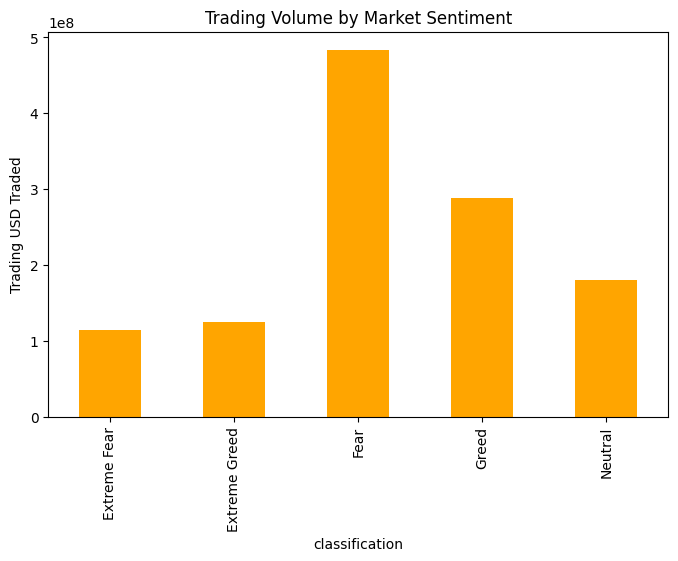

In [38]:
merged_df.groupby('classification')['Size USD'].sum().plot(kind = 'bar', figsize = (8,5), color = 'orange')
plt.title('Trading Volume by Market Sentiment')
plt.ylabel('Trading USD Traded')
plt.show()


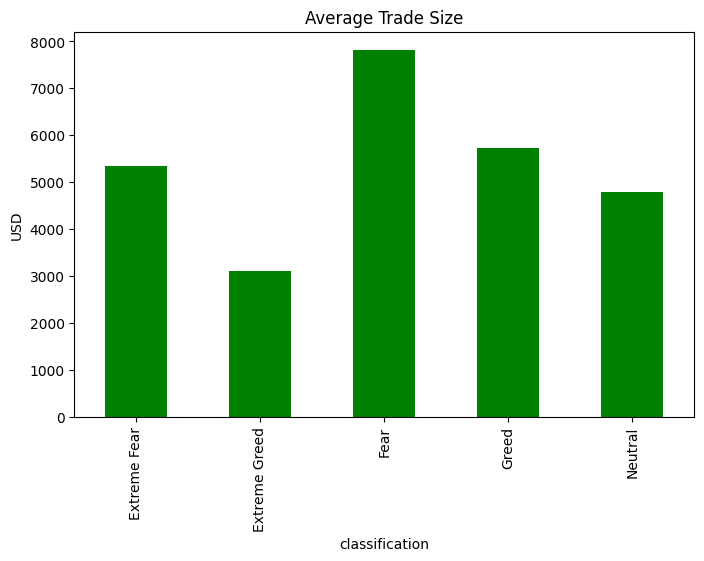

In [39]:
merged_df.groupby('classification')['Size USD'].mean().plot(kind = 'bar', figsize = (8,5), color = 'green')
plt.title('Average Trade Size')
plt.ylabel('USD')
plt.show()

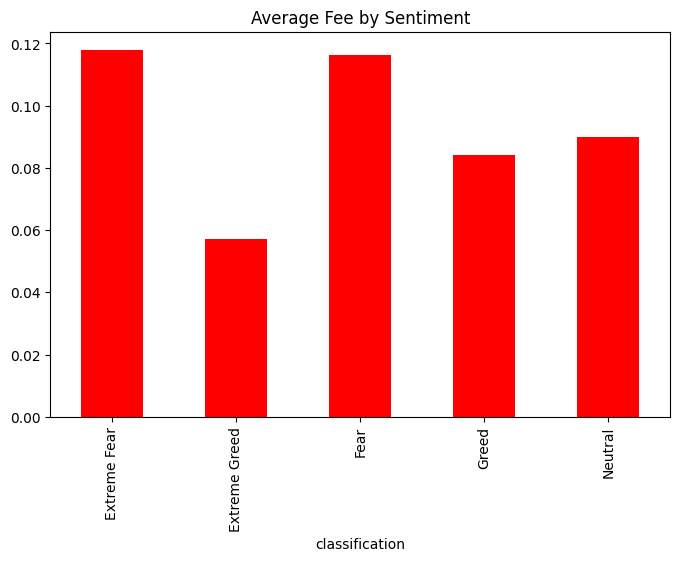

In [40]:
merged_df.groupby('classification')['Fee'].median().plot(kind = 'bar', figsize = (8,5), color = 'red')
plt.title('Average Fee by Sentiment')
plt.show()

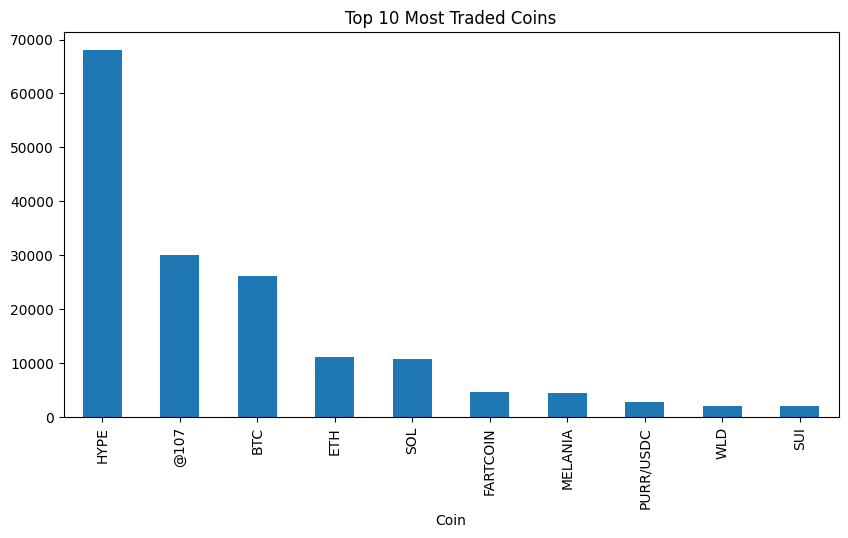

In [41]:
merged_df['Coin'].value_counts().head(10).plot(kind = 'bar', figsize = (10,5))
plt.title('Top 10 Most Traded Coins')
plt.show()

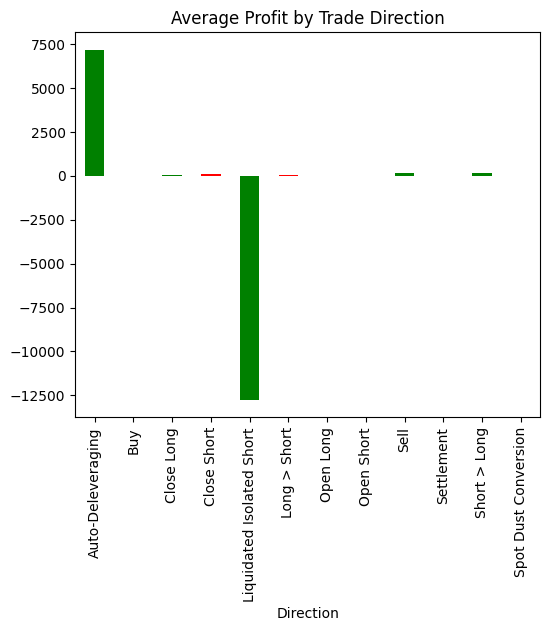

In [42]:
merged_df.groupby('Direction')['Closed PnL'].mean().plot(kind = 'bar', figsize = (6,5), color = ['green', 'red'])
plt.title('Average Profit by Trade Direction')
plt.show()

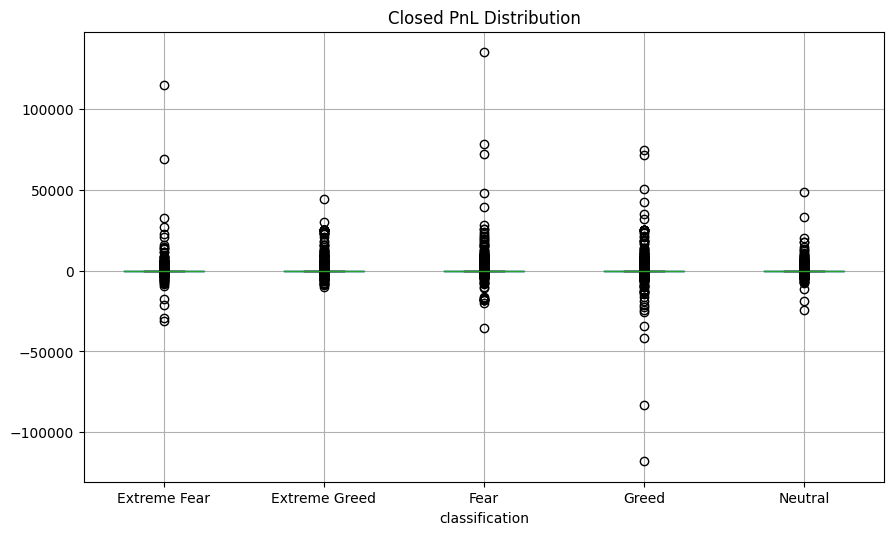

In [45]:
merged_df.boxplot(column = 'Closed PnL', by = 'classification', figsize = (10,6))
plt.title('Closed PnL Distribution')
plt.suptitle('')
plt.show()